In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\moahi\Downloads\Punjab Stubble data 2018-21_Clean and Processed - Raw Data_18.csv")

C:\Users\moahi\AppData\Local\Temp\ipykernel_6204\3662486742.py:3: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\moahi\Downloads\Punjab Stubble data 2018-21_Clean and Processed - Raw Data_18.csv")


In [8]:
df.head()

,Year,District,Block,Satellite,Date,Time (IST),Day / Night,Fire Power(W/m2),Corrected_long,corrected_lat,latlong,Graama,Satellite infrared image reading value indicated stubble burning to the value of
0,2021,Amritsar,Majitha,S-NPP,16-Sep-21,2:06:56 pm,Day,4.8,74.9546,31.7203,74.9546 31.7203,NaN,Satellite infrared image reading value indicat...
1,2021,Amritsar,Tarsikka,S-NPP,16-Sep-21,2:06:56 pm,Day,5.6,75.1281,31.5735,75.1281 31.5735,NaN,Satellite infrared image reading value indicat...
2,2021,PATIALA,PATIALA,S-NPP,18/9/2021,13:29:05,Day,1.8,76.2847,30.2919,76.2847 30.2919,Pasiana,Satellite infrared image reading value indicat...
3,2021,FARIDKOT,KOT KAPURA,S-NPP,18/9/2021,13:29:05,Day,5.4,74.7784,30.5280,74.7784 30.528,Koharwala,Satellite infrared image reading value indicat...
4,2021,AMRITSAR,JANDIALA GURU,S-NPP,18/9/2021,13:29:05,Day,4.3,75.0124,31.6524,75.0124 31.6524,Wila Bajju,Satellite infrared image reading value indicat...


In [10]:
df.shape

(270442, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270442 entries, 0 to 270441
Data columns (total 13 columns):
 #   Column                                                                             Non-Null Count   Dtype  
---  ------                                                                             --------------   -----  
 0   Year                                                                               270442 non-null  int64  
 1   District                                                                           270442 non-null  object 
 2   Block                                                                              270442 non-null  object 
 3   Satellite                                                                          270442 non-null  object 
 4   Date                                                                               270442 non-null  object 
 5   Time (IST)                                                                         270433 non

In [14]:
df.isnull().sum()

Year                                                                                      0
District                                                                                  0
Block                                                                                     0
Satellite                                                                                 0
Date                                                                                      0
Time (IST)                                                                                9
Day / Night                                                                               0
Fire Power(W/m2)                                                                       1419
Corrected_long                                                                            0
corrected_lat                                                                             0
latlong                                                                         

In [16]:
df.duplicated().sum()

14540

In [18]:
df.describe()

,Year,Fire Power(W/m2),Corrected_long,corrected_lat
count,270442.000000,269023.000000,270442.000000,270442.000000
mean,2019.523251,9.054230,75.268971,31.748053
std,1.147754,9.840849,0.599600,7.098703
min,2018.000000,0.200000,73.882450,29.546660
25%,2018.000000,3.700000,74.801122,30.266900
50%,2020.000000,6.000000,75.256520,30.533000
75%,2021.000000,10.500000,75.703898,30.919220
max,2021.000000,406.100000,76.938290,76.238000


In [20]:
df.columns

Index(['Year', 'District', 'Block', 'Satellite', 'Date', 'Time (IST)',
       'Day / Night', 'Fire Power(W/m2)', 'Corrected_long', 'corrected_lat',
       'latlong', 'Graama',
       'Satellite infrared image reading value indicated stubble burning to the value of '],
      dtype='object')

In [26]:
df = df.drop_duplicates()

In [28]:
df.duplicated().sum()

0

In [30]:
df.drop(columns=['Satellite infrared image reading value indicated stubble burning to the value of '], inplace=True)

In [32]:
df.columns

Index(['Year', 'District', 'Block', 'Satellite', 'Date', 'Time (IST)',
       'Day / Night', 'Fire Power(W/m2)', 'Corrected_long', 'corrected_lat',
       'latlong', 'Graama'],
      dtype='object')

In [34]:
df.isnull().sum()

Year                    0
District                0
Block                   0
Satellite               0
Date                    0
Time (IST)              9
Day / Night             0
Fire Power(W/m2)     1419
Corrected_long          0
corrected_lat           0
latlong                 0
Graama              65005
dtype: int64

In [36]:
df = df.dropna(subset=['Fire Power(W/m2)'])

In [38]:
df['Fire Power(W/m2)'].isnull().sum()

0

In [40]:
df = df.dropna(subset=['Time (IST)'])

In [42]:
df['Time (IST)'].isnull().sum()

0

In [44]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

C:\Users\moahi\AppData\Local\Temp\ipykernel_6204\2263964175.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [46]:
df['Date'].dtype

dtype('<M8[ns]')

In [48]:
df['Date'].isnull().sum()

0

In [50]:
df['District'] = df['District'].str.title()

In [52]:
df['District'].unique()[:20]

array(['Amritsar', 'Patiala', 'Faridkot', 'Tarn Taran', 'Sangrur',
       'Ludhiana', 'Firozpur', 'Jalandhar', 'Fazilka', 'Kapurthala',
       'Gurdaspur', 'Muktsar', 'Sbs Nagar', 'Fatehgarh Sahib', 'Rupnagar',
       'Sas Nagar (Mohali)', 'Moga', 'Mansa', 'Barnala', 'Hoshiarpur'],
      dtype=object)

In [54]:
df['Block'] = df['Block'].str.title()

In [58]:
df['Block'].unique()[:20]

array(['Majitha', 'Tarsikka', 'Patiala', 'Kot Kapura', 'Jandiala Guru',
       'Verka', 'Tarn Taran', 'Ajnala', 'Attari', 'Faridkot', 'Dirba',
       'Khadur Sahib', 'Patran', 'Machhiwara', 'Ghall Khurd', 'Lohian',
       'Rayya', 'Chogawan', 'Harsha Chhina', 'Andana'], dtype=object)

In [60]:
df['Graama'] = df['Graama'].fillna('Unknown')

In [62]:
df['Graama'].isnull().sum()

0

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254474 entries, 0 to 270441
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Year              254474 non-null  int64         
 1   District          254474 non-null  object        
 2   Block             254474 non-null  object        
 3   Satellite         254474 non-null  object        
 4   Date              254474 non-null  datetime64[ns]
 5   Time (IST)        254474 non-null  object        
 6   Day / Night       254474 non-null  object        
 7   Fire Power(W/m2)  254474 non-null  float64       
 8   Corrected_long    254474 non-null  float64       
 9   corrected_lat     254474 non-null  float64       
 10  latlong           254474 non-null  object        
 11  Graama            254474 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 25.2+ MB


In [66]:
df.isnull().sum()

Year                0
District            0
Block               0
Satellite           0
Date                0
Time (IST)          0
Day / Night         0
Fire Power(W/m2)    0
Corrected_long      0
corrected_lat       0
latlong             0
Graama              0
dtype: int64

In [68]:
df.to_csv("Punjab_Stubble_Clean.csv", index=False)

In [70]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 254474
Columns: 12


In [73]:
df['Year'].value_counts().sort_index()

Year
2018    59614
2019    49355
2020    75304
2021    70201
Name: count, dtype: int64

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Q1. How many incidents were recorded each year?

In [81]:
df['Year'].value_counts().sort_index()

Year
2018    59614
2019    49355
2020    75304
2021    70201
Name: count, dtype: int64

### Insight

• 2020 recorded the highest number of stubble burning incidents.
• 2019 had the lowest number of recorded incidents.

## Q2. How many districts are covered in the dataset?

In [85]:
df['District'].nunique()

26

## Q3. Which districts have the highest number of stubble burning incidents?

In [88]:
df['District'].value_counts().head(10)

District
Sangrur       32821
Firozpur      27619
Bathinda      23667
Muktsar       19212
Patiala       18242
Mansa         15983
Moga          15447
Ludhiana      15202
Barnala       15059
Tarn Taran    14371
Name: count, dtype: int64

## Q4. Which blocks have the highest number of stubble burning incidents?

In [93]:
top_blocks = df['Block'].value_counts().head(10)

top_blocks

Block
Zira            9634
Firozpur        9218
Bathinda        8400
Barnala         8284
Sunam           8263
Faridkot        7926
Jalalabad       7850
Rampura Phul    6964
Muktsar         6853
Patti           6604
Name: count, dtype: int64

## Q5. During which time of the day do most stubble burning incidents occur?

In [96]:
df['Day / Night'].value_counts()

Day / Night
Day      254307
Night       167
Name: count, dtype: int64

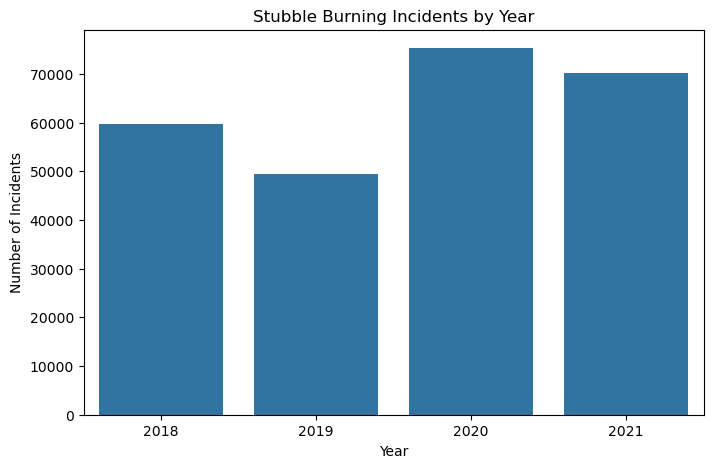

In [98]:
year_count = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=year_count.index,
    y=year_count.values
)

plt.title("Stubble Burning Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")

plt.show()

### Insight

• The highest number of stubble burning incidents occurred in 2020 (75,304), followed by 2021 (70,201).
• A noticeable increase in incidents is observed after 2019, indicating higher burning activity during 2020–2021.

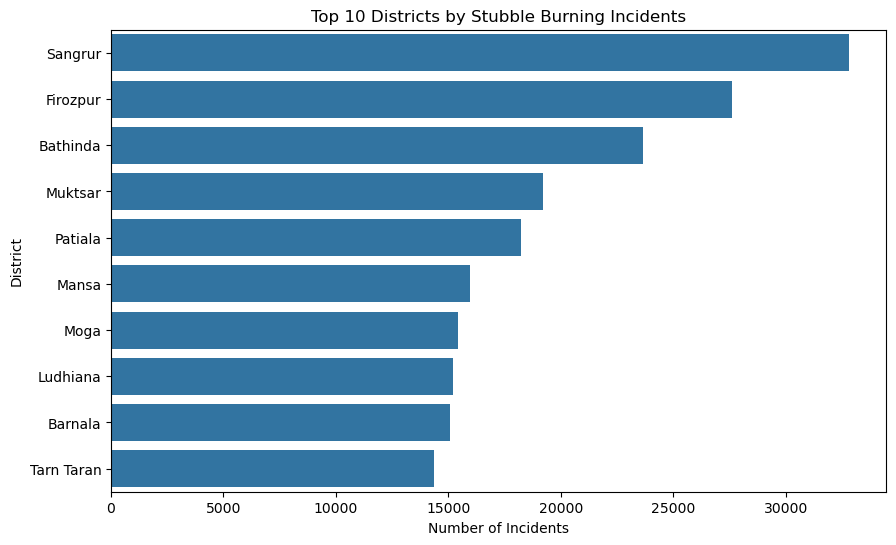

In [105]:
district = df['District'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=district.values,
    y=district.index
)

plt.title("Top 10 Districts by Stubble Burning Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("District")

plt.show()

### Insight

• Sangrur recorded the highest number of stubble burning incidents (32,821), followed by Firozpur (27,619) and Bathinda (23,667).
• These districts account for a significant share of total incidents and may require targeted policy interventions.

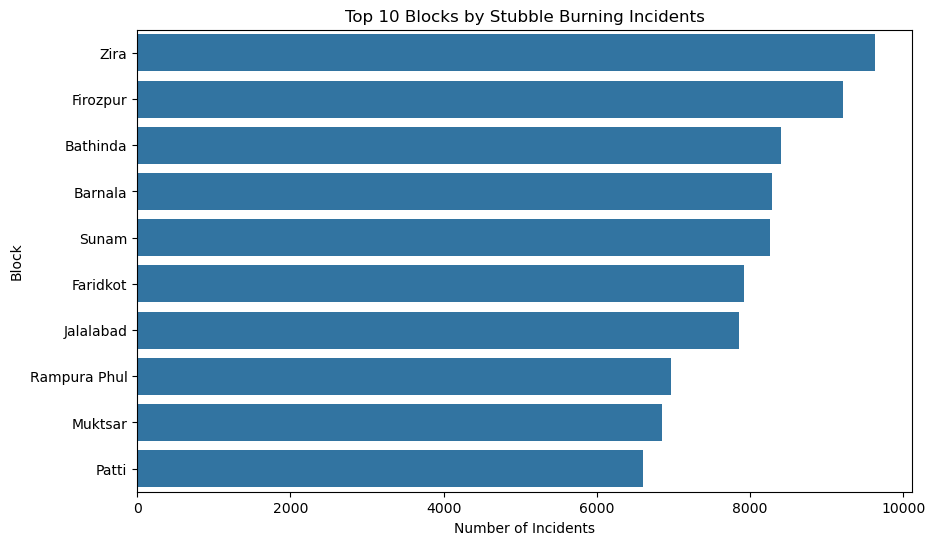

In [108]:
top_blocks = df['Block'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_blocks.values,
    y=top_blocks.index
)

plt.title("Top 10 Blocks by Stubble Burning Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Block")

plt.show()

### Insight

• The analysis identifies the top 10 blocks contributing to stubble burning incidents.
• These blocks can be prioritized for awareness programs, monitoring, and sustainable crop residue management initiatives.

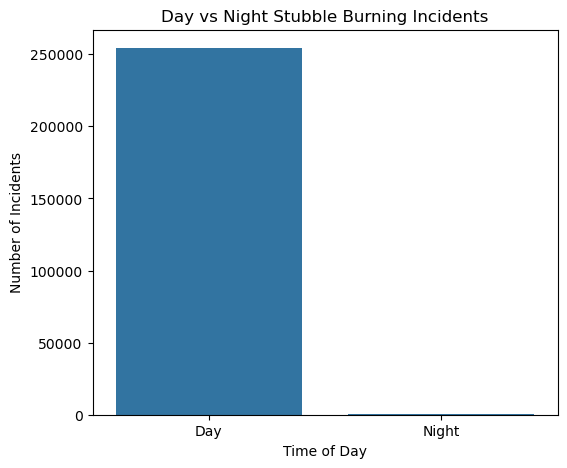

In [111]:
day = df['Day / Night'].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=day.index,
    y=day.values
)

plt.title("Day vs Night Stubble Burning Incidents")
plt.xlabel("Time of Day")
plt.ylabel("Number of Incidents")

plt.show()

### Insight

• Most stubble burning incidents were detected during the daytime, indicating that agricultural burning activities predominantly occur during daylight hours.

In [114]:
df['Month'] = df['Date'].dt.month_name()

# Order months correctly
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

month_count = df['Month'].value_counts().reindex(month_order)

month_count

Month
January        1809
February       3001
March          2521
April          3055
May            4420
June           3984
July           5271
August         4505
September      5386
October       87054
November     129970
December       3498
Name: count, dtype: int64

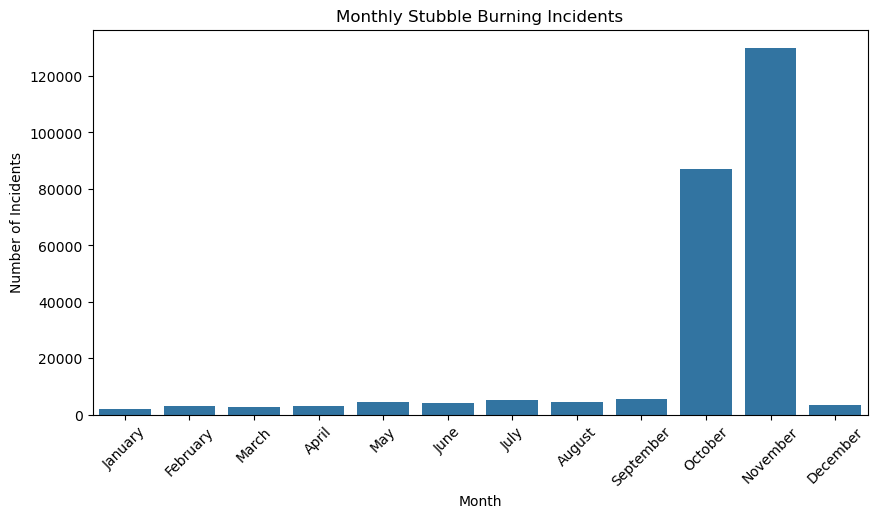

In [116]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=month_count.index,
    y=month_count.values
)

plt.title("Monthly Stubble Burning Incidents")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.xticks(rotation=45)

plt.show()

### Insight

• Stubble burning incidents are concentrated in a few specific months rather than being evenly distributed throughout the year.

• The peak months indicate the post-harvest period when crop residue burning is most common.

• These findings can help authorities schedule awareness campaigns and enforcement activities before the peak burning season.

# Key Findings

• A total of 254,474 cleaned records were analyzed from 2018–2021.

• 2020 recorded the highest number of stubble burning incidents.

• Sangrur reported the highest number of incidents, followed by Firozpur and Bathinda.

• Most incidents occurred during daytime and were concentrated during the post-harvest months.

• Several districts consistently recorded higher average fire power, indicating more severe burning activity.

# Conclusion

The analysis identifies key temporal and geographical patterns in Punjab's stubble burning incidents. These insights can support policymakers and local authorities in planning targeted awareness campaigns, improving monitoring efforts, and implementing sustainable crop residue management practices.

# Data Storytelling

The analysis of Punjab's stubble burning dataset (2018–2021) reveals clear temporal and geographical patterns in crop residue burning activities. Although incidents were reported across multiple districts, a small number of districts consistently contributed the majority of cases.

The analysis also shows that burning activities are concentrated during specific months associated with the post-harvest season and occur predominantly during daytime. Additionally, certain districts not only reported more incidents but also recorded higher average fire intensity, indicating regions that may require greater attention.

These findings highlight opportunities for policymakers to implement targeted awareness campaigns, strengthen monitoring efforts during peak months, and encourage sustainable alternatives to crop residue burning.

# Recommendations

• Prioritize monitoring in districts with consistently high incident counts.

• Launch awareness campaigns before the peak stubble burning season.

• Promote sustainable crop residue management practices among farmers.

• Increase satellite-based monitoring during high-risk months.

• Focus intervention efforts on districts with higher average fire intensity.

# Conclusion

This project demonstrates how data analytics can transform large environmental datasets into meaningful insights. By combining data cleaning, exploratory data analysis, and visualization, the study identifies key trends in Punjab's stubble burning activities and provides evidence-based recommendations that can support environmental planning and policy decisions.